In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### Вирішила одразу видалити 6 колонок оскільки при відсутності інформації > 50%, колонкою можна знехтувати.

In [5]:
drop_df = df.drop(columns=["MiscFeature", "Fence", "PoolQC", "FireplaceQu", "MasVnrType", "Alley"])
drop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

#### Створю 'initial' X та y для перевірки точності передбачень навчених моделей

In [87]:
num_features = drop_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = drop_df.select_dtypes(include=["object"]).columns.tolist()
X_test_init = drop_df[num_features + cat_features].drop(columns=["SalePrice"])
y_test_init = np.log(drop_df["SalePrice"])
X_test_init.shape, y_test_init.shape

((1460, 74), (1460,))

#### Спробуємо створити матрицю кореляцій і подивитись які ознаки реально впливають на таргет "SalePrice"

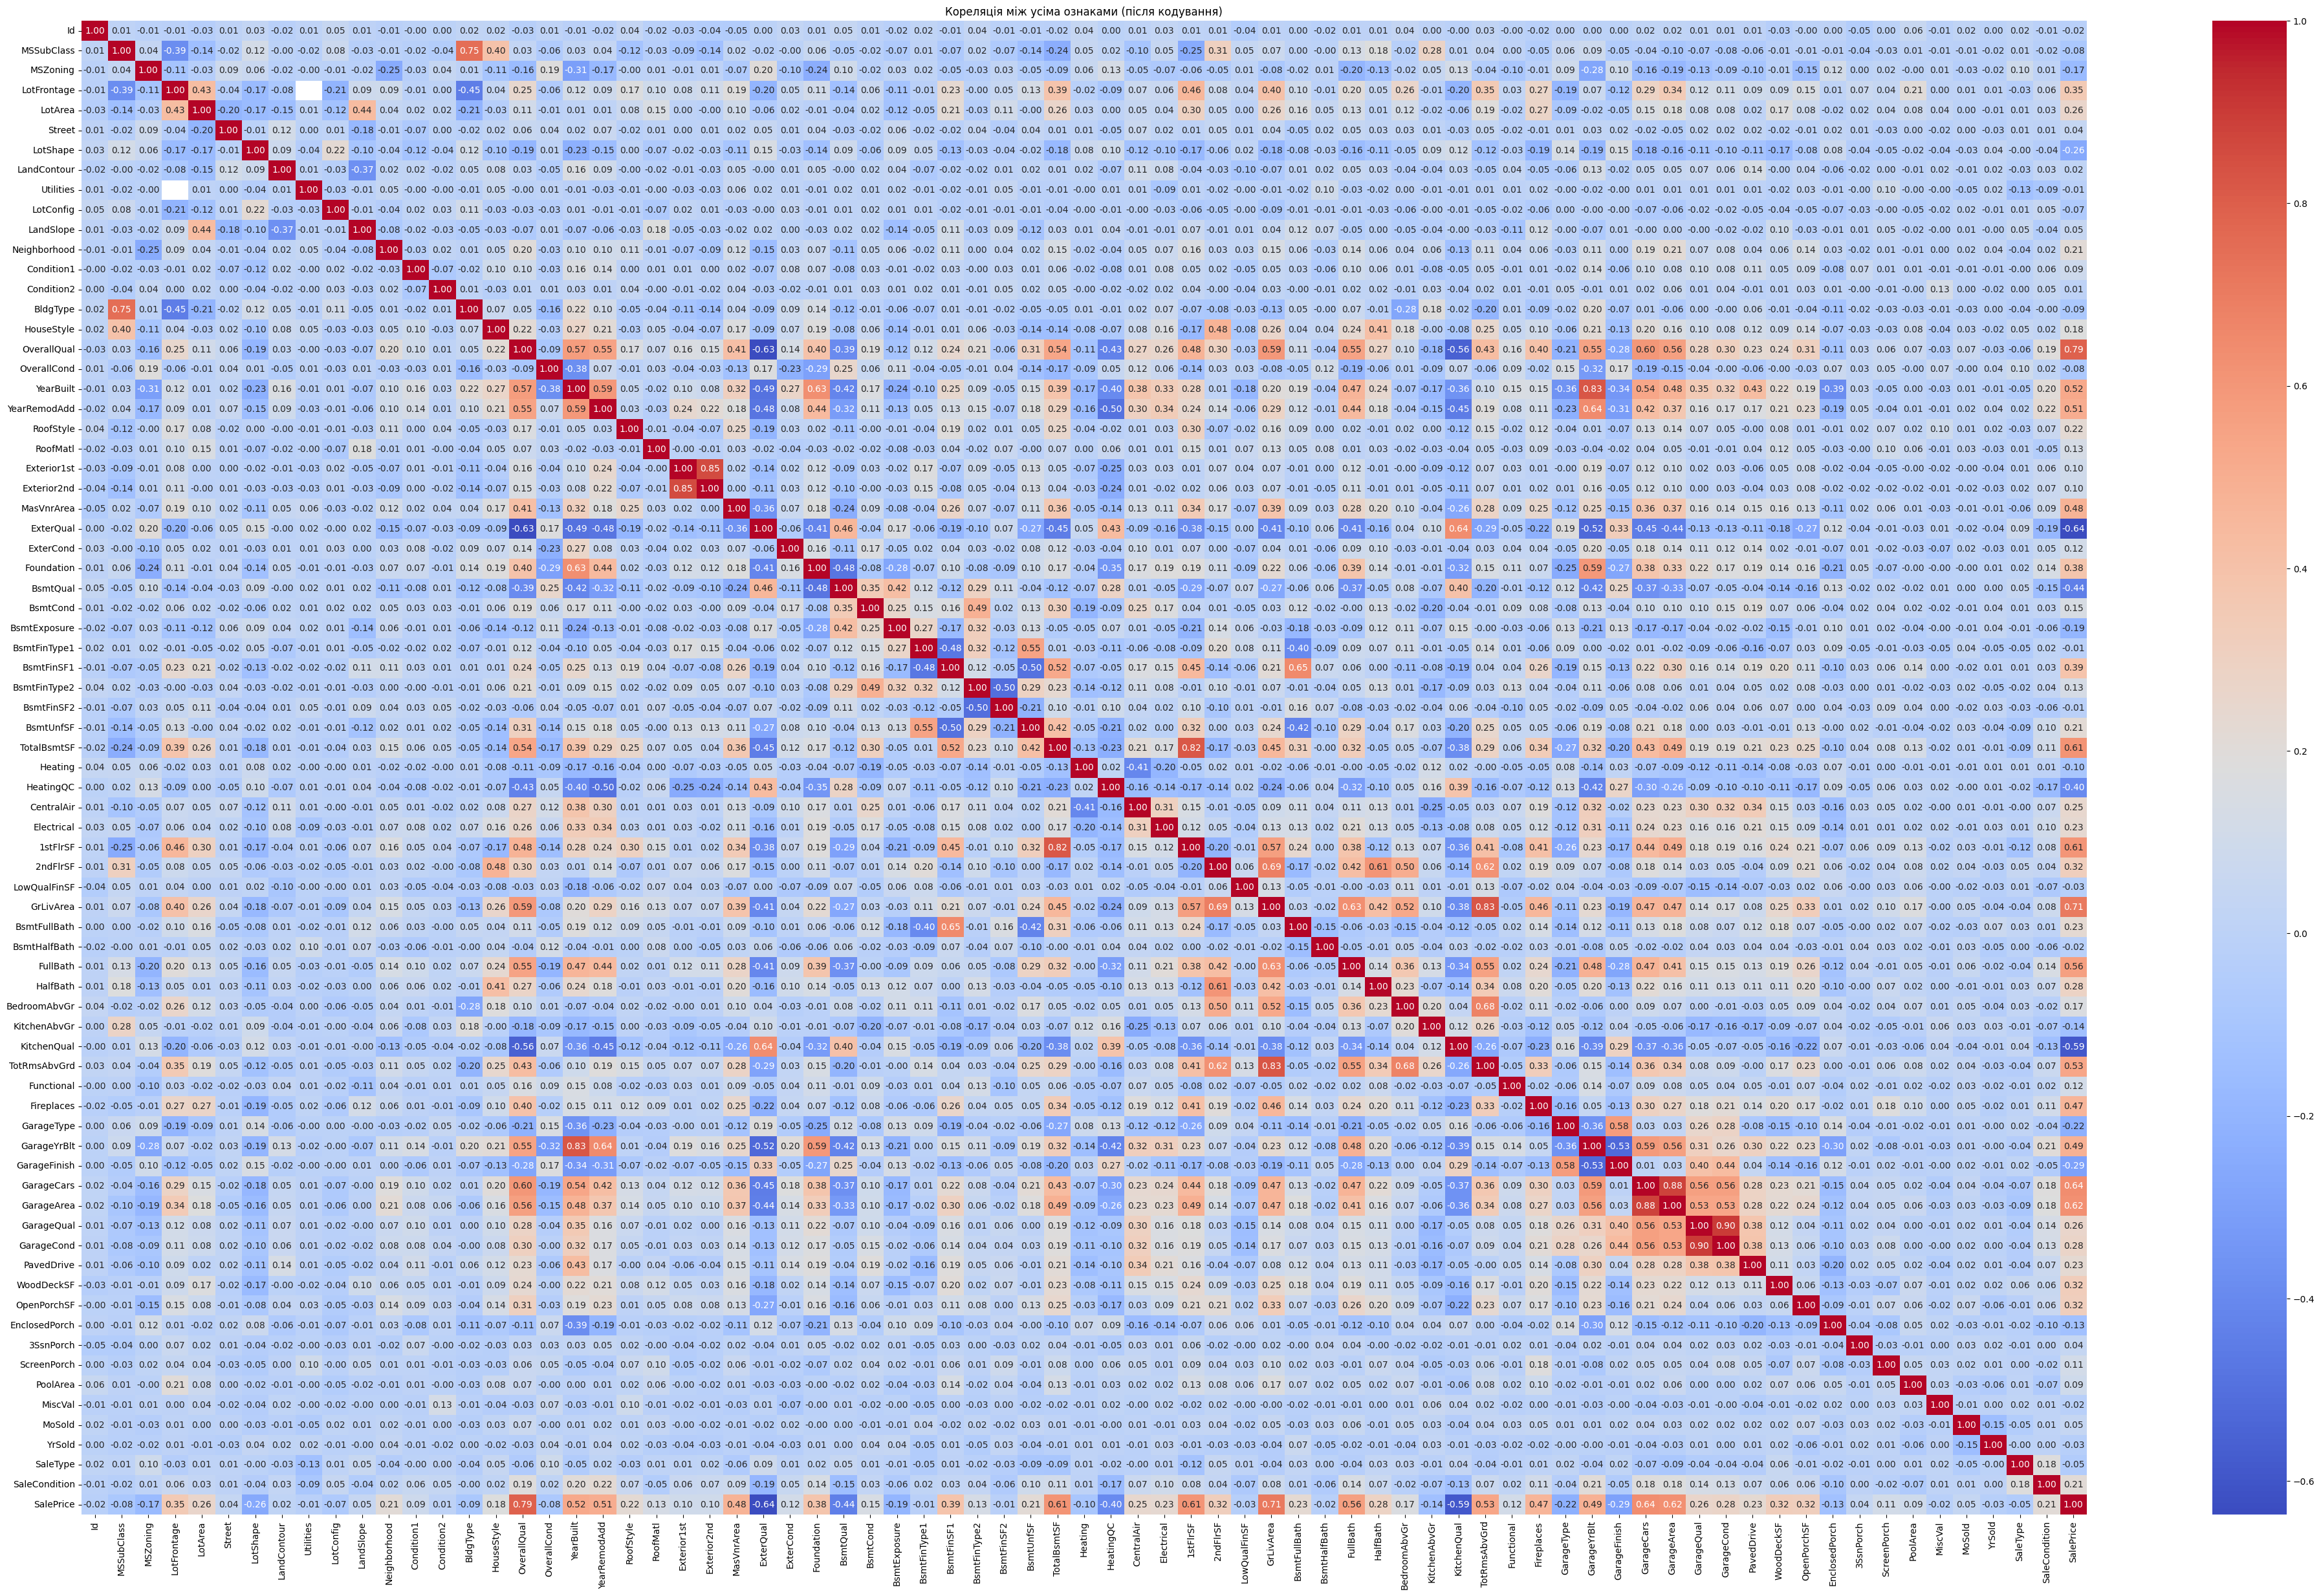

In [23]:
df_enc = drop_df.copy()

for col in df_enc.select_dtypes(include=["object"]).columns:
    df_enc[col] = df_enc[col].astype("category").cat.codes

corr_matrix = df_enc.corr()
plt.figure(figsize=(50, 30))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляція між усіма ознаками (після кодування)")
plt.show()

#### Забагато ознак. Спробуємо прибрати з найменшою кореляцією.

In [24]:
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_triangle = corr_matrix.where(mask)

strong_correlations = upper_triangle.stack().reset_index()

strong_correlations.columns = ['Feature 1', 'Feature 2', 'Correlation']

min_corr = 0.12
unique_strong_list = strong_correlations[strong_correlations['Correlation'].abs() > min_corr]
unique_strong_list = unique_strong_list.sort_values(by='Correlation', ascending=False, key=abs)

In [25]:
unique_strong_list[unique_strong_list["Feature 2"] == "SalePrice"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 1120 to 2737
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Feature 1    47 non-null     object 
 1   Feature 2    47 non-null     object 
 2   Correlation  47 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB


In [26]:
model1_df = unique_strong_list[unique_strong_list["Feature 2"] == "SalePrice"]

#### Маю список з 47 ознак які найбільше впливають на таргет "SalePrice".

In [27]:
model1_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 1120 to 2737
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Feature 1    47 non-null     object 
 1   Feature 2    47 non-null     object 
 2   Correlation  47 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB


In [28]:
needed_features = model1_df["Feature 1"].unique().tolist()
model1_filtered = drop_df[needed_features]
model1_filtered

,OverallQual,GrLivArea,GarageCars,ExterQual,GarageArea,TotalBsmtSF,1stFlrSF,KitchenQual,FullBath,TotRmsAbvGrd,...,Neighborhood,BsmtExposure,HouseStyle,BedroomAbvGr,MSZoning,BsmtCond,KitchenAbvGr,RoofMatl,BsmtFinType2,EnclosedPorch
0,7,1710,2,Gd,548,856,856,Gd,2,8,...,CollgCr,No,2Story,3,RL,TA,1,CompShg,Unf,0
1,6,1262,2,TA,460,1262,1262,TA,2,6,...,Veenker,Gd,1Story,3,RL,TA,1,CompShg,Unf,0
2,7,1786,2,Gd,608,920,920,Gd,2,6,...,CollgCr,Mn,2Story,3,RL,TA,1,CompShg,Unf,0
3,7,1717,3,TA,642,756,961,Gd,1,7,...,Crawfor,No,2Story,3,RL,Gd,1,CompShg,Unf,272
4,8,2198,3,Gd,836,1145,1145,Gd,2,9,...,NoRidge,Av,2Story,4,RL,TA,1,CompShg,Unf,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,TA,460,953,953,TA,2,7,...,Gilbert,No,2Story,3,RL,TA,1,CompShg,Unf,0
1456,6,2073,2,TA,500,1542,2073,TA,2,7,...,NWAmes,No,1Story,3,RL,TA,1,CompShg,Rec,0
1457,7,2340,1,Ex,252,1152,1188,Gd,2,9,...,Crawfor,No,2Story,4,RL,Gd,1,CompShg,Unf,0
1458,5,1078,1,TA,240,1078,1078,Gd,1,5,...,NAmes,Mn,1Story,2,RL,TA,1,CompShg,Rec,112


#### Спробуємо позбутись мультиколінеарності. Візьмемо кореляції > 0,9 і приберемо кілька ознак.

In [29]:
unique_strong_list[:5]

,Feature 1,Feature 2,Correlation
2669,GarageQual,GarageCond,0.902991
2638,GarageCars,GarageArea,0.882475
1396,Exterior1st,Exterior2nd,0.854163
1215,YearBuilt,GarageYrBlt,0.825667
2316,GrLivArea,TotRmsAbvGrd,0.825489


#### Маємо дві ознаки з кореляцією > 0,9.  
#### GarageQual: Garage quality
#### GarageCond: Garage condition
#### Дропну GarageQual

In [30]:
df1_filt = model1_filtered.drop(columns=["GarageQual"])
df1_filt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 46 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OverallQual    1460 non-null   int64  
 1   GrLivArea      1460 non-null   int64  
 2   GarageCars     1460 non-null   int64  
 3   ExterQual      1460 non-null   object 
 4   GarageArea     1460 non-null   int64  
 5   TotalBsmtSF    1460 non-null   int64  
 6   1stFlrSF       1460 non-null   int64  
 7   KitchenQual    1460 non-null   object 
 8   FullBath       1460 non-null   int64  
 9   TotRmsAbvGrd   1460 non-null   int64  
 10  YearBuilt      1460 non-null   int64  
 11  YearRemodAdd   1460 non-null   int64  
 12  GarageYrBlt    1379 non-null   float64
 13  MasVnrArea     1452 non-null   float64
 14  Fireplaces     1460 non-null   int64  
 15  BsmtQual       1423 non-null   object 
 16  HeatingQC      1460 non-null   object 
 17  BsmtFinSF1     1460 non-null   int64  
 18  Foundati

#### Perform an Exploratory Data Analysis (“EDA”) on the dataset (using the columns you’ve chosen), 
#### including visualization and descriptive statistics. Interpret the results and describe them in your own words.

#### Після вивчення файлу з даними було прийнято рішення прибрати ознаки з відсутністю значень > 50%.
#### Потім була створена матриця кореляцій яка дала можливість визначити ознаки які найбільш корелюються з таргетом.
#### Останнім кроком було відкинуто одну ознаку, щоб позбутися явної мультиколінеарності (кореляція ознак > 0.9)
#### В результаті маємо датасет df1_filt з 46 ознак, спробуємо з ним працювати.

In [31]:
df1_filt.head()

,OverallQual,GrLivArea,GarageCars,ExterQual,GarageArea,TotalBsmtSF,1stFlrSF,KitchenQual,FullBath,TotRmsAbvGrd,...,Neighborhood,BsmtExposure,HouseStyle,BedroomAbvGr,MSZoning,BsmtCond,KitchenAbvGr,RoofMatl,BsmtFinType2,EnclosedPorch
0,7,1710,2,Gd,548,856,856,Gd,2,8,...,CollgCr,No,2Story,3,RL,TA,1,CompShg,Unf,0
1,6,1262,2,TA,460,1262,1262,TA,2,6,...,Veenker,Gd,1Story,3,RL,TA,1,CompShg,Unf,0
2,7,1786,2,Gd,608,920,920,Gd,2,6,...,CollgCr,Mn,2Story,3,RL,TA,1,CompShg,Unf,0
3,7,1717,3,TA,642,756,961,Gd,1,7,...,Crawfor,No,2Story,3,RL,Gd,1,CompShg,Unf,272
4,8,2198,3,Gd,836,1145,1145,Gd,2,9,...,NoRidge,Av,2Story,4,RL,TA,1,CompShg,Unf,0


#### Use a “regular” train-test split with hyperparameter optimization using cross validation (i.e. GridSearchCV). 
#### Explain which hyperparameters you are optimizing and what space is being explored for each hyperparameter.
#### Include appropriate preprocessing steps - missing value imputation, scaling, feature encoding.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [33]:
num_features = df1_filt.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = df1_filt.select_dtypes(include=["object"]).columns.tolist()

In [34]:
df["SalePrice"].info() # порожні значення/NaN відсутні

<class 'pandas.core.series.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: SalePrice
Non-Null Count  Dtype
--------------  -----
1460 non-null   int64
dtypes: int64(1)
memory usage: 11.5 KB


In [35]:
X = df1_filt[num_features + cat_features]
y = df["SalePrice"]
X.shape, y.shape

((1460, 46), (1460,))

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1022, 46), (438, 46), (1022,), (438,))

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer

In [38]:
def DTRegressor(num_features, cat_features, max_depth=5, n_estimators=50):
    
    numeric_pipeline = Pipeline([
         ("imputer", SimpleImputer(strategy='median')),
         ("scaler", StandardScaler())
    ])
    
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("one_hot", OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop="if_binary"))
    ])
    
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, num_features),
        ("cat", categorical_pipeline, cat_features)
    ])
    
    full_pipeline = Pipeline([
        
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(criterion='absolute_error', max_depth=max_depth, random_state=11))
    ])

    return full_pipeline

In [39]:
test_1 = DTRegressor(num_features, cat_features, 5)

test_1.fit(X_train, y_train)
y_pred_1 = test_1.predict(X_test)

C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9, 19] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [40]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score, mean_absolute_error

In [41]:
def metrics(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"MSE: {mse:.3f}"
          f"\nRMSE: {rmse:.3f}"
          f"\nMAE : {mae:.3f}"
          f"\nR2: {r2:.3f}")

In [42]:
metrics(y_test, y_pred_1)

MSE: 2575664286.247
RMSE: 50751.003
MAE : 28568.821
R2: 0.602


#### Маємо таке собі значення R2 (треба підвищити min до 0.85 як для фінансових показників), 
#### але усі інші розрахунки вказують на значні викиди у таргеті, спробуємо їх прибрати.
#### І збільшимо гіперпараметр глибини для нашого дерева до 10

In [43]:
X = df1_filt[num_features + cat_features]
y = np.log(df["SalePrice"])
X.shape, y.shape

((1460, 46), (1460,))

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1022, 46), (438, 46), (1022,), (438,))

In [45]:
test_2 = DTRegressor(num_features, cat_features, 10)

test_2.fit(X_train, y_train)
y_pred_2 = test_2.predict(X_test)

C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9, 19] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [46]:
metrics(y_test, y_pred_2)

MSE: 0.049
RMSE: 0.221
MAE : 0.149
R2: 0.684


#### Логорифмування таргету допомогло зменшити вплив викидів у таргеті. Збільшення глибини теж покращило результат.

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
test_3 = DTRegressor(num_features, cat_features)

In [49]:
param_grid = {
    'model__max_depth': [3, 5, 8, 12, 15, None],
    'model__min_samples_leaf': [1, 2, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__max_features': ['sqrt', 'log2', None],
    'model__criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

In [50]:
grid_search = GridSearchCV(
    estimator=test_3,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [51]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1080 candidates, totalling 5400 fits


,estimator,Pipeline(step...m_state=11))])
,param_grid,"{'model__criterion': ['squared_error', 'friedman_mse', ...], 'model__max_depth': [3, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [52]:
print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Найкращий R2 на крос-валідації: {grid_search.best_score_:.3f}")

Найкращі параметри: {'model__criterion': 'absolute_error', 'model__max_depth': 8, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 20}
Найкращий R2 на крос-валідації: 0.782


In [53]:
y_pred_3 = grid_search.predict(X_test)

C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9, 19] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [54]:
metrics(y_test, y_pred_3)

MSE: 0.042
RMSE: 0.206
MAE : 0.140
R2: 0.726


#### Свій результат ми покращили, тепер візуалізуємо дані, повернемо наші таргети до реальних значень (підемо від логарифму)

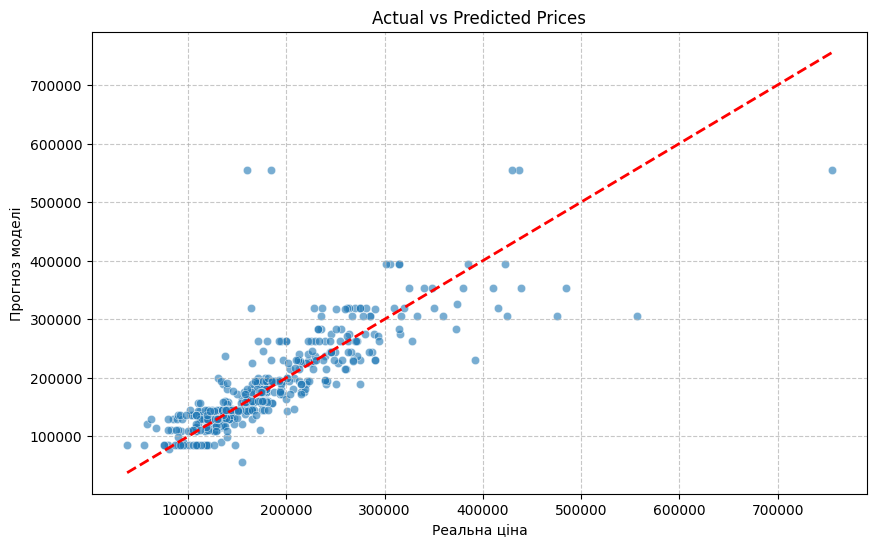

In [55]:
y_actual = np.exp(y_test)
y_predicted = np.exp(y_pred_3)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_actual, y=y_predicted, alpha=0.6, edgecolor="w")
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], "r--", lw=2)

plt.xlabel("Реальна ціна")
plt.ylabel("Прогноз моделі")
plt.title(f"Actual vs Predicted Prices")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [56]:
error_percent = ((y_predicted - y_actual) / y_actual) * 100

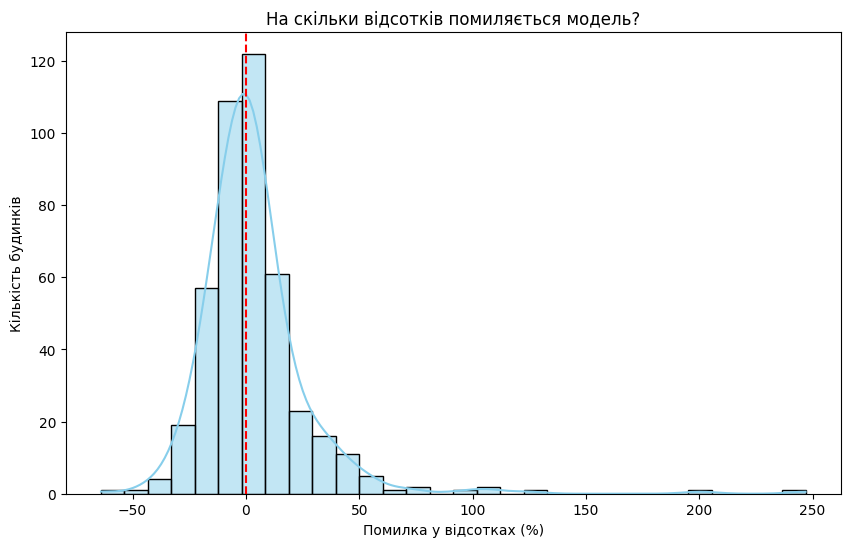

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(error_percent, kde=True, bins=30, color="skyblue")
plt.axvline(x=0, color="red", linestyle="--")

plt.xlabel("Помилка у відсотках (%)")
plt.ylabel("Кількість будинків")
plt.title("На скільки відсотків помиляється модель?")
plt.show()

#### Загалом наша модель досить стабільна, але ми маємо дуже довгий хвіст праворуч, 
#### на якихось об'єктах модель помиляється дуже сильно, і це псує оцінку точності.

#### Знайдемо будтнки де наша модель помилилась найбільше і вивчимо їх.

In [58]:
res_df = pd.DataFrame({
    "Actual_Log": y_test,
    "Predicted_Log": y_pred_3,
    "Actual_Price": np.exp(y_test),
    "Predicted_Price": np.exp(y_pred_3)
}, index=X_test.index)

In [59]:
res_df.head()

,Actual_Log,Predicted_Log,Actual_Price,Predicted_Price
503,12.574182,12.524526,289000.0,275000.000000
101,12.089539,12.206073,178000.0,200000.000000
608,12.791356,12.632079,359100.0,306226.048859
1089,12.190959,12.345835,197000.0,230000.000000
819,12.319401,12.321631,224000.0,224500.000000


In [60]:
res_df["Error_Abs"] = abs(res_df["Actual_Price"] - res_df["Predicted_Price"])

res_df["Error_Percent"] = (res_df["Error_Abs"] / res_df["Actual_Price"]) * 100

worst_predictions = res_df.sort_values(by="Error_Abs", ascending=False).head(10)
worst_predictions

,Actual_Log,Predicted_Log,Actual_Price,Predicted_Price,Error_Abs,Error_Percent
1298,11.982929,13.226723,160000.0,555000.000000,395000.000000,246.875000
523,12.126759,13.226723,184750.0,555000.000000,370250.000000,200.405954
1046,13.229568,12.632079,556581.0,306226.048859,250354.951141,44.980866
691,13.534473,13.226723,755000.0,555000.000000,200000.000000,26.490066
185,13.071070,12.632079,475000.0,306226.048859,168773.951141,35.531358
688,12.879017,12.345835,392000.0,230000.000000,162000.000000,41.326531
1211,12.007622,12.673037,164000.0,319029.026893,155029.026893,94.529894
798,13.091904,12.777052,485000.0,354000.000000,131000.000000,27.010309
496,12.971540,13.226723,430000.0,555000.000000,125000.000000,29.069767
1142,12.959539,12.632079,424870.0,306226.048859,118643.951141,27.924765


In [61]:
outliers_high = res_df[res_df["Error_Percent"] > 50]
outliers_high

,Actual_Log,Predicted_Log,Actual_Price,Predicted_Price,Error_Abs,Error_Percent
1453,11.344507,11.775290,84500.0,130000.000000,45500.000000,53.846154
145,11.775290,12.206073,130000.0,200000.000000,70000.000000,53.846154
137,12.049419,12.478006,171000.0,262500.000000,91500.000000,53.508772
1211,12.007622,12.673037,164000.0,319029.026893,155029.026893,94.529894
17,11.407565,11.827259,90000.0,136934.655949,46934.655949,52.149618
968,10.542706,11.349818,37900.0,84949.985285,47049.985285,124.142441
1178,11.950535,10.930549,154900.0,55856.960175,99043.039825,63.939987
398,11.112448,11.652687,67000.0,115000.000000,48000.000000,71.641791
705,10.915088,11.349818,55000.0,84949.985285,29949.985285,54.454519
1380,10.976782,11.699405,58500.0,120500.000000,62000.000000,105.982906


In [62]:
outlier_indices = outliers_high.index

df.loc[outlier_indices]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1453,1454,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,84500
145,146,160,RM,24.0,2522,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,130000
137,138,90,RL,82.0,11070,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Family,171000
1211,1212,50,RL,152.0,12134,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,164000
17,18,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
968,969,50,RM,50.0,5925,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,5,2009,WD,Abnorml,37900
1178,1179,50,RL,54.0,7681,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,154900
398,399,30,RM,60.0,8967,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Abnorml,67000
705,706,190,RM,70.0,5600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Othr,3500,7,2010,WD,Normal,55000
1380,1381,30,RL,45.0,8212,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,58500


#### Цікаво, що буде як прибрати ці будинки з датасету.
#### Створимо наступний датасет де приберемо проблемні об'єкти та трохи підвищимо значення мінімальної кореляції.

In [63]:
drop_df_2 = drop_df.drop(index=outlier_indices)

In [64]:
df_enc_2 = drop_df_2.copy()

for col in df_enc_2.select_dtypes(include=["object"]).columns:
    df_enc_2[col] = df_enc_2[col].astype("category").cat.codes

corr_matrix_2 = df_enc_2.corr()

mask = np.triu(np.ones(corr_matrix_2.shape), k=1).astype(bool)
upper_triangle = corr_matrix_2.where(mask)

strong_correlations = upper_triangle.stack().reset_index()

strong_correlations.columns = ['Feature 1', 'Feature 2', 'Correlation']

min_corr = 0.14
unique_strong_list = strong_correlations[strong_correlations['Correlation'].abs() > min_corr]
unique_strong_list = unique_strong_list.sort_values(by='Correlation', ascending=False, key=abs)

In [65]:
unique_strong_list[unique_strong_list["Feature 2"] == "SalePrice"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 1120 to 218
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Feature 1    42 non-null     object 
 1   Feature 2    42 non-null     object 
 2   Correlation  42 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.3+ KB


In [66]:
model2_df = unique_strong_list[unique_strong_list["Feature 2"] == "SalePrice"]

In [67]:
needed_features = model2_df["Feature 1"].unique().tolist()
model2_filtered = drop_df_2[needed_features]
model2_filtered.head()

,OverallQual,GrLivArea,TotalBsmtSF,ExterQual,GarageCars,1stFlrSF,GarageArea,KitchenQual,FullBath,TotRmsAbvGrd,...,GarageType,BsmtFullBath,RoofStyle,BsmtUnfSF,Neighborhood,SaleCondition,BsmtExposure,HouseStyle,BedroomAbvGr,MSZoning
0,7,1710,856,Gd,2,856,548,Gd,2,8,...,Attchd,1,Gable,150,CollgCr,Normal,No,2Story,3,RL
1,6,1262,1262,TA,2,1262,460,TA,2,6,...,Attchd,0,Gable,284,Veenker,Normal,Gd,1Story,3,RL
2,7,1786,920,Gd,2,920,608,Gd,2,6,...,Attchd,1,Gable,434,CollgCr,Normal,Mn,2Story,3,RL
3,7,1717,756,TA,3,961,642,Gd,1,7,...,Detchd,1,Gable,540,Crawfor,Abnorml,No,2Story,3,RL
4,8,2198,1145,Gd,3,1145,836,Gd,2,9,...,Attchd,1,Gable,490,NoRidge,Normal,Av,2Story,4,RL


In [68]:
unique_strong_list[:5]

,Feature 1,Feature 2,Correlation
2669,GarageQual,GarageCond,0.902966
2638,GarageCars,GarageArea,0.885566
1396,Exterior1st,Exterior2nd,0.853668
2316,GrLivArea,TotRmsAbvGrd,0.830041
1215,YearBuilt,GarageYrBlt,0.823813


In [69]:
df2_filt = model2_filtered.drop(columns=["GarageQual", "GarageCars"])
df2_filt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1445 entries, 0 to 1459
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OverallQual    1445 non-null   int64  
 1   GrLivArea      1445 non-null   int64  
 2   TotalBsmtSF    1445 non-null   int64  
 3   ExterQual      1445 non-null   object 
 4   1stFlrSF       1445 non-null   int64  
 5   GarageArea     1445 non-null   int64  
 6   KitchenQual    1445 non-null   object 
 7   FullBath       1445 non-null   int64  
 8   TotRmsAbvGrd   1445 non-null   int64  
 9   YearBuilt      1445 non-null   int64  
 10  YearRemodAdd   1445 non-null   int64  
 11  GarageYrBlt    1368 non-null   float64
 12  MasVnrArea     1437 non-null   float64
 13  Fireplaces     1445 non-null   int64  
 14  BsmtQual       1410 non-null   object 
 15  BsmtFinSF1     1445 non-null   int64  
 16  HeatingQC      1445 non-null   object 
 17  Foundation     1445 non-null   object 
 18  LotFrontage  

In [70]:
num_features = df2_filt.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = df2_filt.select_dtypes(include=["object"]).columns.tolist()

In [71]:
X_2 = df2_filt[num_features + cat_features]
y_2 = np.log(drop_df_2["SalePrice"])
X_2.shape, y_2.shape

((1445, 40), (1445,))

In [78]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.3, random_state=2)
X_train_2.shape, X_test_2.shape, y_train_2.shape, y_test_2.shape

((1011, 40), (434, 40), (1011,), (434,))

In [79]:
test_4 = DTRegressor(num_features, cat_features, 12)

test_4.fit(X_train_2, y_train_2)
y_pred_4 = test_4.predict(X_test_2)

C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [80]:
metrics(y_test_2, y_pred_4)

MSE: 0.044
RMSE: 0.209
MAE : 0.145
R2: 0.718


In [83]:
y_actual = np.exp(y_test_2)
y_predicted = np.exp(y_pred_4)

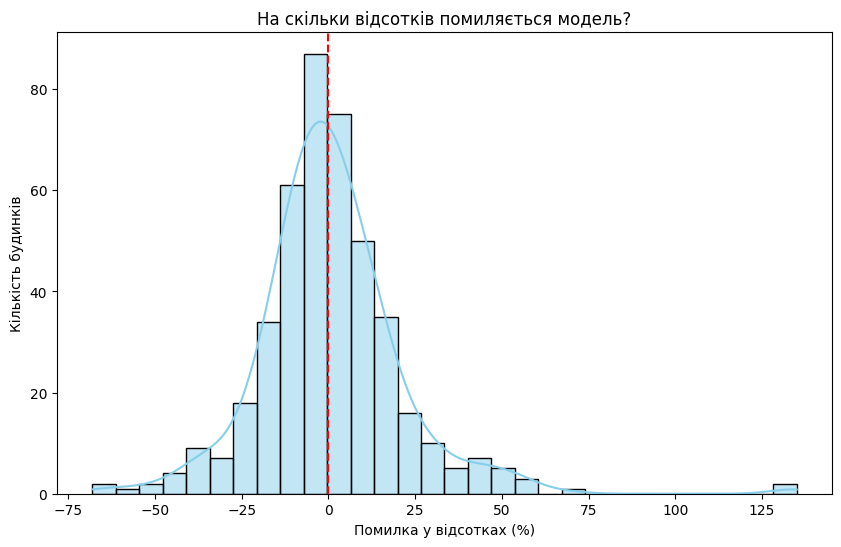

In [84]:
error_percent = ((y_predicted - y_actual) / y_actual) * 100
plt.figure(figsize=(10, 6))
sns.histplot(error_percent, kde=True, bins=30, color="skyblue")
plt.axvline(x=0, color="red", linestyle="--")

plt.xlabel("Помилка у відсотках (%)")
plt.ylabel("Кількість будинків")
plt.title("На скільки відсотків помиляється модель?")
plt.show()

#### Відчутно зменшили наш хвіст праворуч.

#### Наша тестова модель test_4 навчилася на відфільтрованих даних, 
#### спробуємо зробити передбачення на 'initial' даних які підготували на початку роботи.

In [89]:
y_pred_5 = test_4.predict(X_test_init)
metrics(y_test_init, y_pred_5)

MSE: 0.017
RMSE: 0.131
MAE : 0.059
R2: 0.892


C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


#### Маємо наче гарний результат. MAE та RMSE стали трохи ближчими, 
#### значить ми позбулись сильних викидів, про що також свідчить гістограмма, де зменшили хвіст помилок праворуч.
#### Модель тепер більш рівномірна. Найбільша кількість помилок зосереджена в діапазоні +- 10 %.
#### Було прийнято рішення не використовувати PCA у даному навчанні, не так багато в нас ознак.
#### PCA не дасть значного приросту для R2.
#### У поточній роботі були задіяні наступні кроки обробки даних та подальшого навчання:
####  - Аналіз оригінальних даних (прибрали одразу зовсім порожні ознаки)
####  - За допомогою матриці кореляцій визначили які саме ознаки найбільш впливають на таргет (їх лишили, інші прибрала з датасету)
####  - У пайплайні зазначила заповнення порожніх значень медіаною, та стандартну регуляризацію даних для числових значень. Заповнення "модою", та OneHotEncoding для категоріальних значень.
####  - В якості моделі була обрана DecisionTreeRegressor.
####  - Розрахунки були виконані в двох екземплярах, навчання з GridSearchCV та без нього для порівняння.

#### Навчивши останню модель на обробленному датасеті, отримали передбачення з високою точністю, що дуже гарний показник.